In [1]:
!pip install pandas numpy matplotlib seaborn missingno -q

In [2]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
DATA_PATH = "/content/drive/MyDrive/sepsis-prediction/training_data"

In [6]:
csv_files = {}

for file in os.listdir(DATA_PATH):
    if file.endswith(".csv"):
        path = os.path.join(DATA_PATH, file)
        csv_files[file] = pd.read_csv(path)

print("Files Loaded:")
for file in csv_files:
    print(file)

Files Loaded:
drugsexposure_train.csv
measurement_meds_train.csv
observation_train.csv
SepsisLabel_train.csv
measurement_lab_train.csv
person_demographics_episode_train.csv
measurement_observation_train.csv
devices_train.csv
proceduresoccurrences_train.csv


In [7]:
for name, df in csv_files.items():
    print("="*80)
    print("Dataset:", name)
    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())
    print()

Dataset: drugsexposure_train.csv
Shape: (184780, 5)
Columns:
['visit_occurrence_id', 'person_id', 'drug_datetime_hourly', 'drug_concept_id', 'route_concept_id']

Dataset: measurement_meds_train.csv
Shape: (257749, 10)
Columns:
['visit_occurrence_id', 'person_id', 'measurement_datetime', 'Systolic blood pressure', 'Diastolic blood pressure', 'Body temperature', 'Respiratory rate', 'Heart rate', 'Measurement of oxygen saturation at periphery', 'Oxygen/Gas total [Pure volume fraction] Inhaled gas']

Dataset: observation_train.csv
Shape: (3807, 6)
Columns:
['visit_occurrence_id', 'person_id', 'observation_datetime', 'observation_concept_id', 'observation_concept_name', 'valuefilled']

Dataset: SepsisLabel_train.csv
Shape: (331653, 3)
Columns:
['person_id', 'measurement_datetime', 'SepsisLabel']

Dataset: measurement_lab_train.csv
Shape: (69307, 40)
Columns:
['visit_occurrence_id', 'person_id', 'measurement_datetime', 'Base excess in Venous blood by calculation', 'Base excess in Arterial bl

In [8]:
for name, df in csv_files.items():

    print("="*80)
    print(name)

    print("\nShape:")
    print(df.shape)

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    print("\nMemory Usage:")
    print(df.memory_usage(deep=True).sum()/1024**2,"MB")

drugsexposure_train.csv

Shape:
(184780, 5)

Data Types:
visit_occurrence_id      int64
person_id                int64
drug_datetime_hourly    object
drug_concept_id         object
route_concept_id        object
dtype: object

Missing Values:
visit_occurrence_id      0
person_id                0
drug_datetime_hourly     0
drug_concept_id          0
route_concept_id        22
dtype: int64

Duplicate Rows:
1851

Memory Usage:
35.768409729003906 MB
measurement_meds_train.csv

Shape:
(257749, 10)

Data Types:
visit_occurrence_id                                      int64
person_id                                                int64
measurement_datetime                                    object
Systolic blood pressure                                float64
Diastolic blood pressure                               float64
Body temperature                                       float64
Respiratory rate                                       float64
Heart rate                                      

In [9]:
import hashlib

def get_file_hash(df):
    return hashlib.md5(
        pd.util.hash_pandas_object(df).values
    ).hexdigest()

hash_dict = {}

for name, df in csv_files.items():
    hash_dict[name] = get_file_hash(df)

print("Duplicate File Check\n")

for f1,h1 in hash_dict.items():
    for f2,h2 in hash_dict.items():

        if f1 != f2 and h1 == h2:
            print(f"{f1} == {f2}")

Duplicate File Check



In [10]:
label_file = None

for name in csv_files.keys():
    if "SepsisLabel" in name:
        label_file = name

print("Using:", label_file)

label_df = csv_files[label_file]

label_df.head()

Using: SepsisLabel_train.csv


,person_id,measurement_datetime,SepsisLabel
0,274096387,2024-12-03 20:00:00,0
1,1719359031,2024-04-20 09:00:00,0
2,2024544816,2021-07-14 07:00:00,0
3,213710896,2022-05-24 07:00:00,0
4,1335786468,2024-08-25 22:00:00,0


In [11]:
label_col = "SepsisLabel"

label_df[label_col].value_counts()

,count
SepsisLabel,
0,324779
1,6874


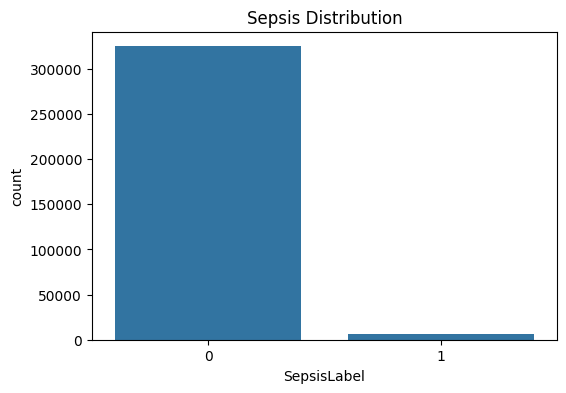

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=label_df[label_col]
)

plt.title("Sepsis Distribution")
plt.show()

In [13]:
percent = label_df[label_col].value_counts(normalize=True)*100

print(percent)

SepsisLabel
0    97.927352
1     2.072648
Name: proportion, dtype: float64


In [14]:
demo_file = None

for name in csv_files.keys():
    if "person_demographics" in name:
        demo_file = name

print(demo_file)

demo_df = csv_files[demo_file]

demo_df.head()

person_demographics_episode_train.csv


,visit_occurrence_id,person_id,visit_start_date,birth_datetime,age_in_months,gender
0,1933014304,1354145347,2021-12-15,2002-05-30,235,MALE
1,469091308,1211327821,2020-01-28,2002-03-23,214,MALE
2,822483951,127099706,2020-06-01,2003-01-15,209,MALE
3,862311390,60715713,2021-02-14,2003-02-21,216,MALE
4,960347036,2088110327,2020-07-24,2003-02-16,209,MALE


In [15]:
patient_col = demo_df.columns[0]

print("Unique Patients:",
      demo_df[patient_col].nunique())

Unique Patients: 3391


In [16]:
numeric_cols = demo_df.select_dtypes(
    include=np.number
).columns

numeric_cols

Index(['visit_occurrence_id', 'person_id', 'age_in_months'], dtype='object')

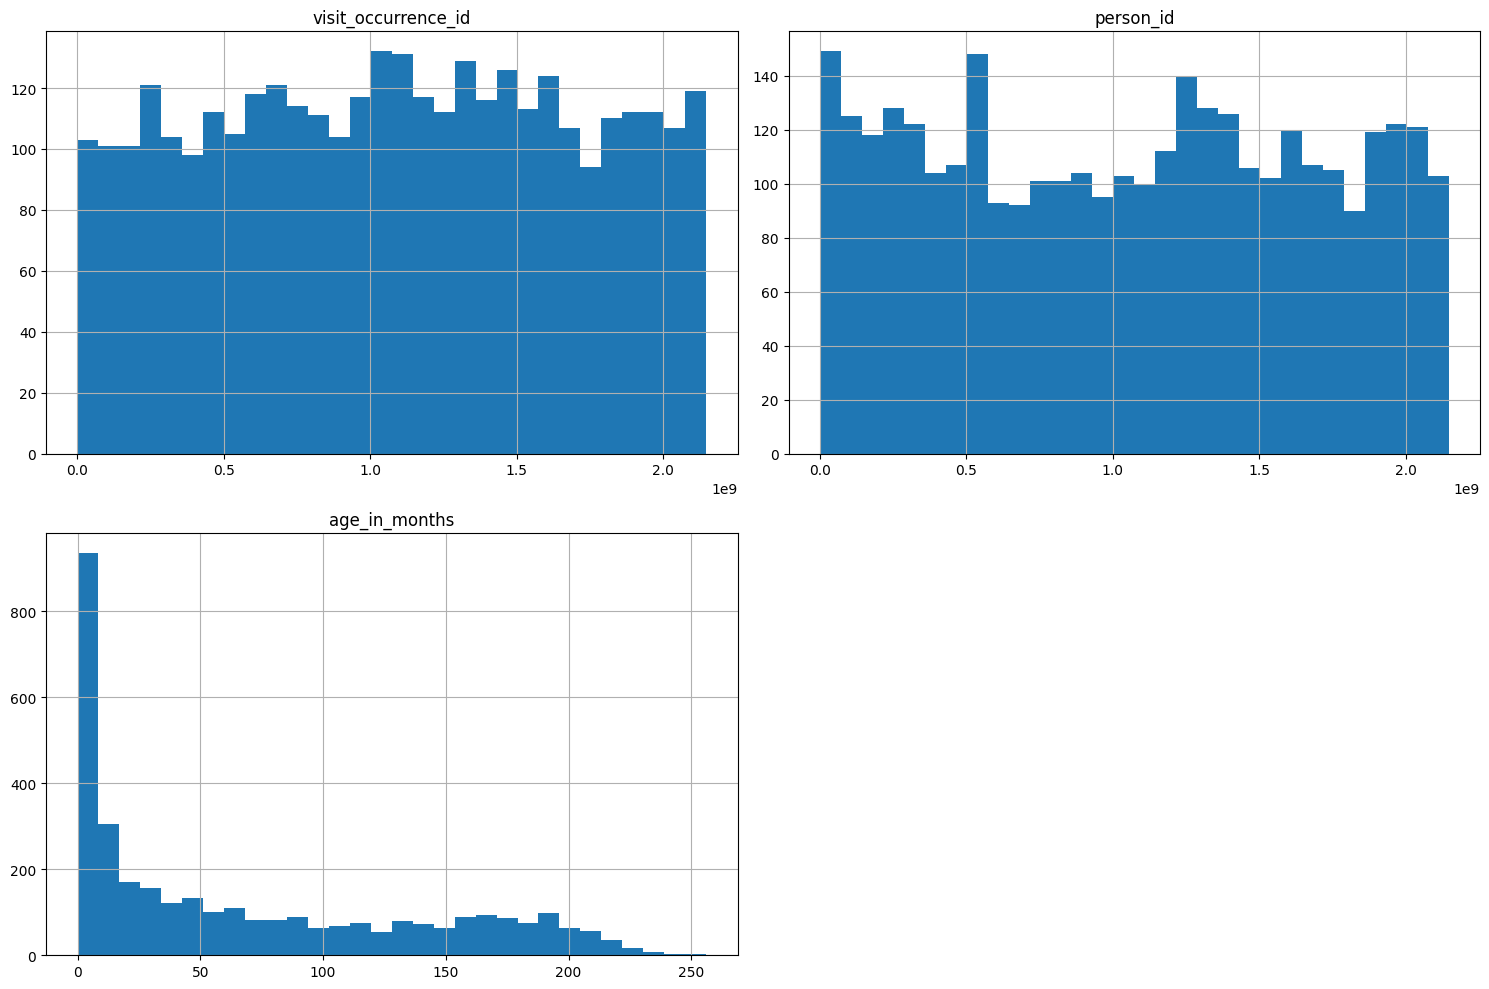

In [17]:
demo_df[numeric_cols].hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

drugsexposure_train.csv


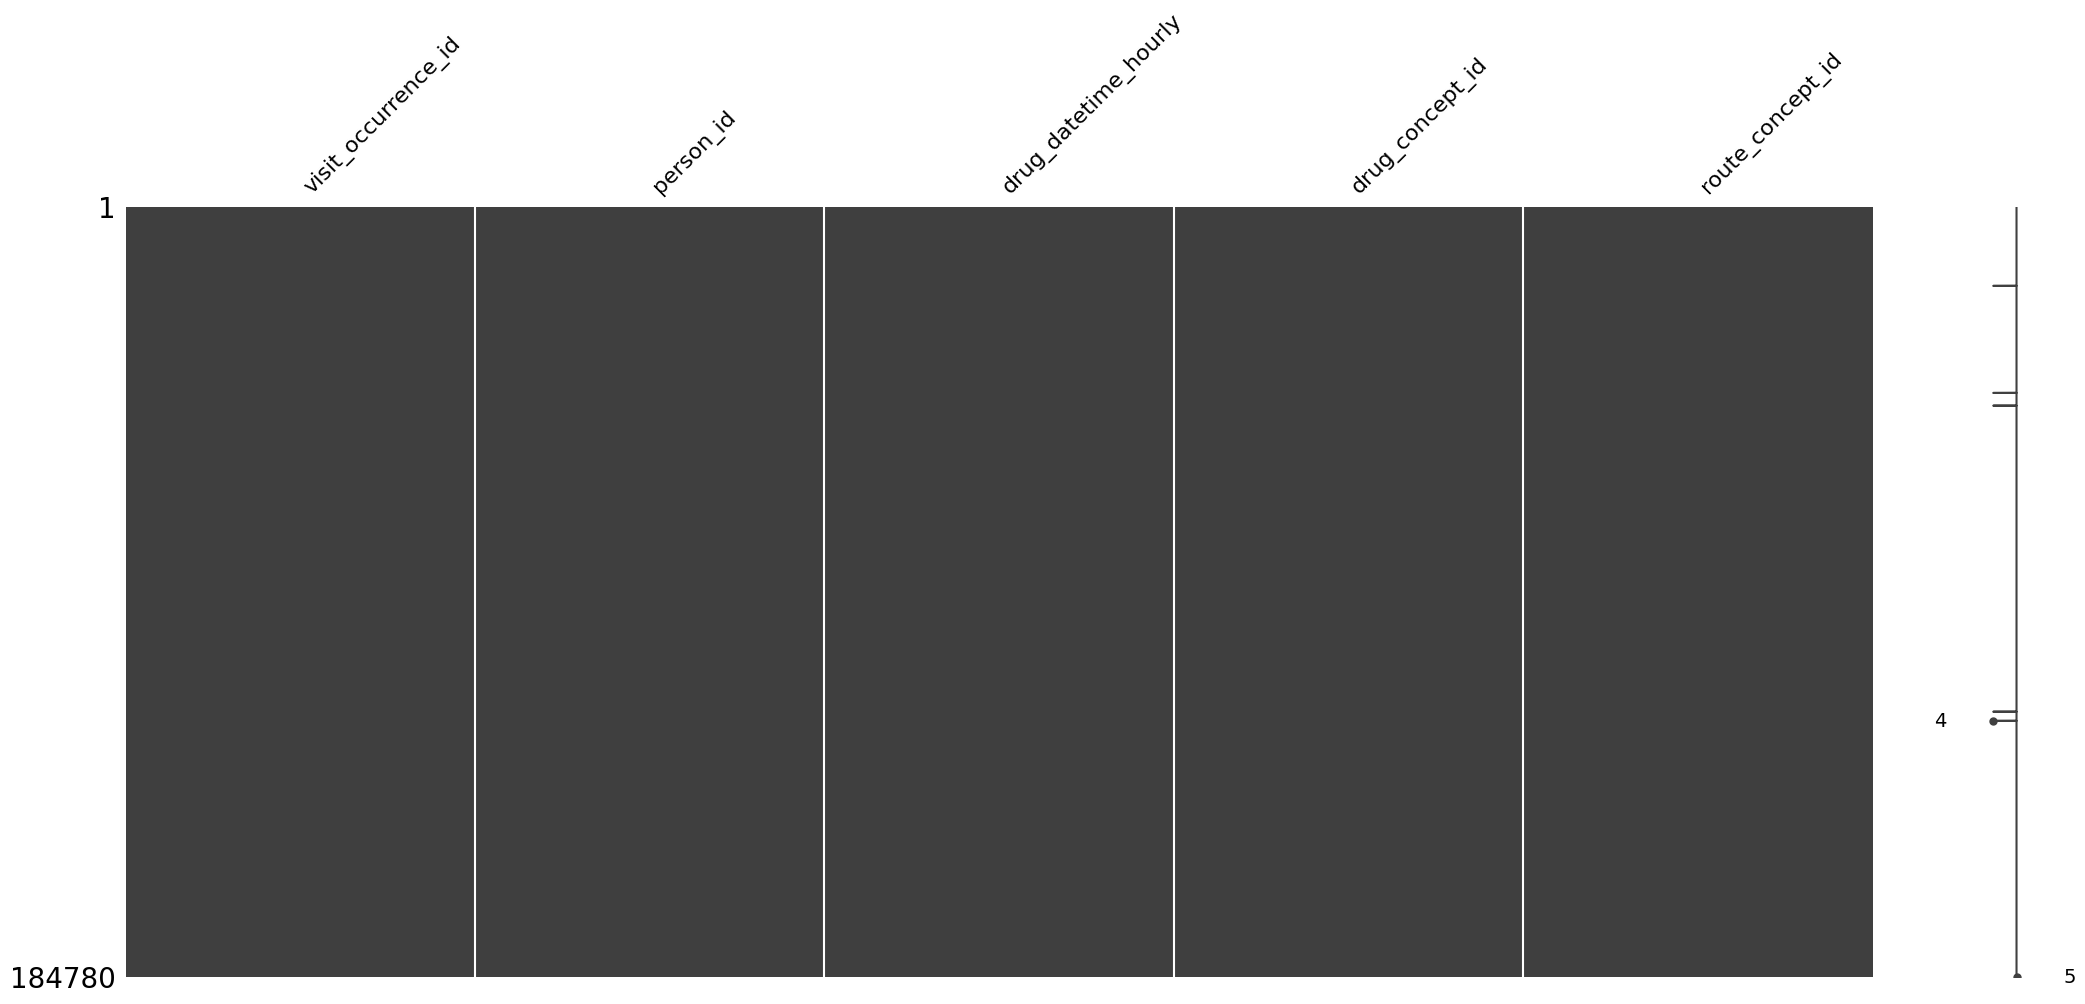

measurement_meds_train.csv


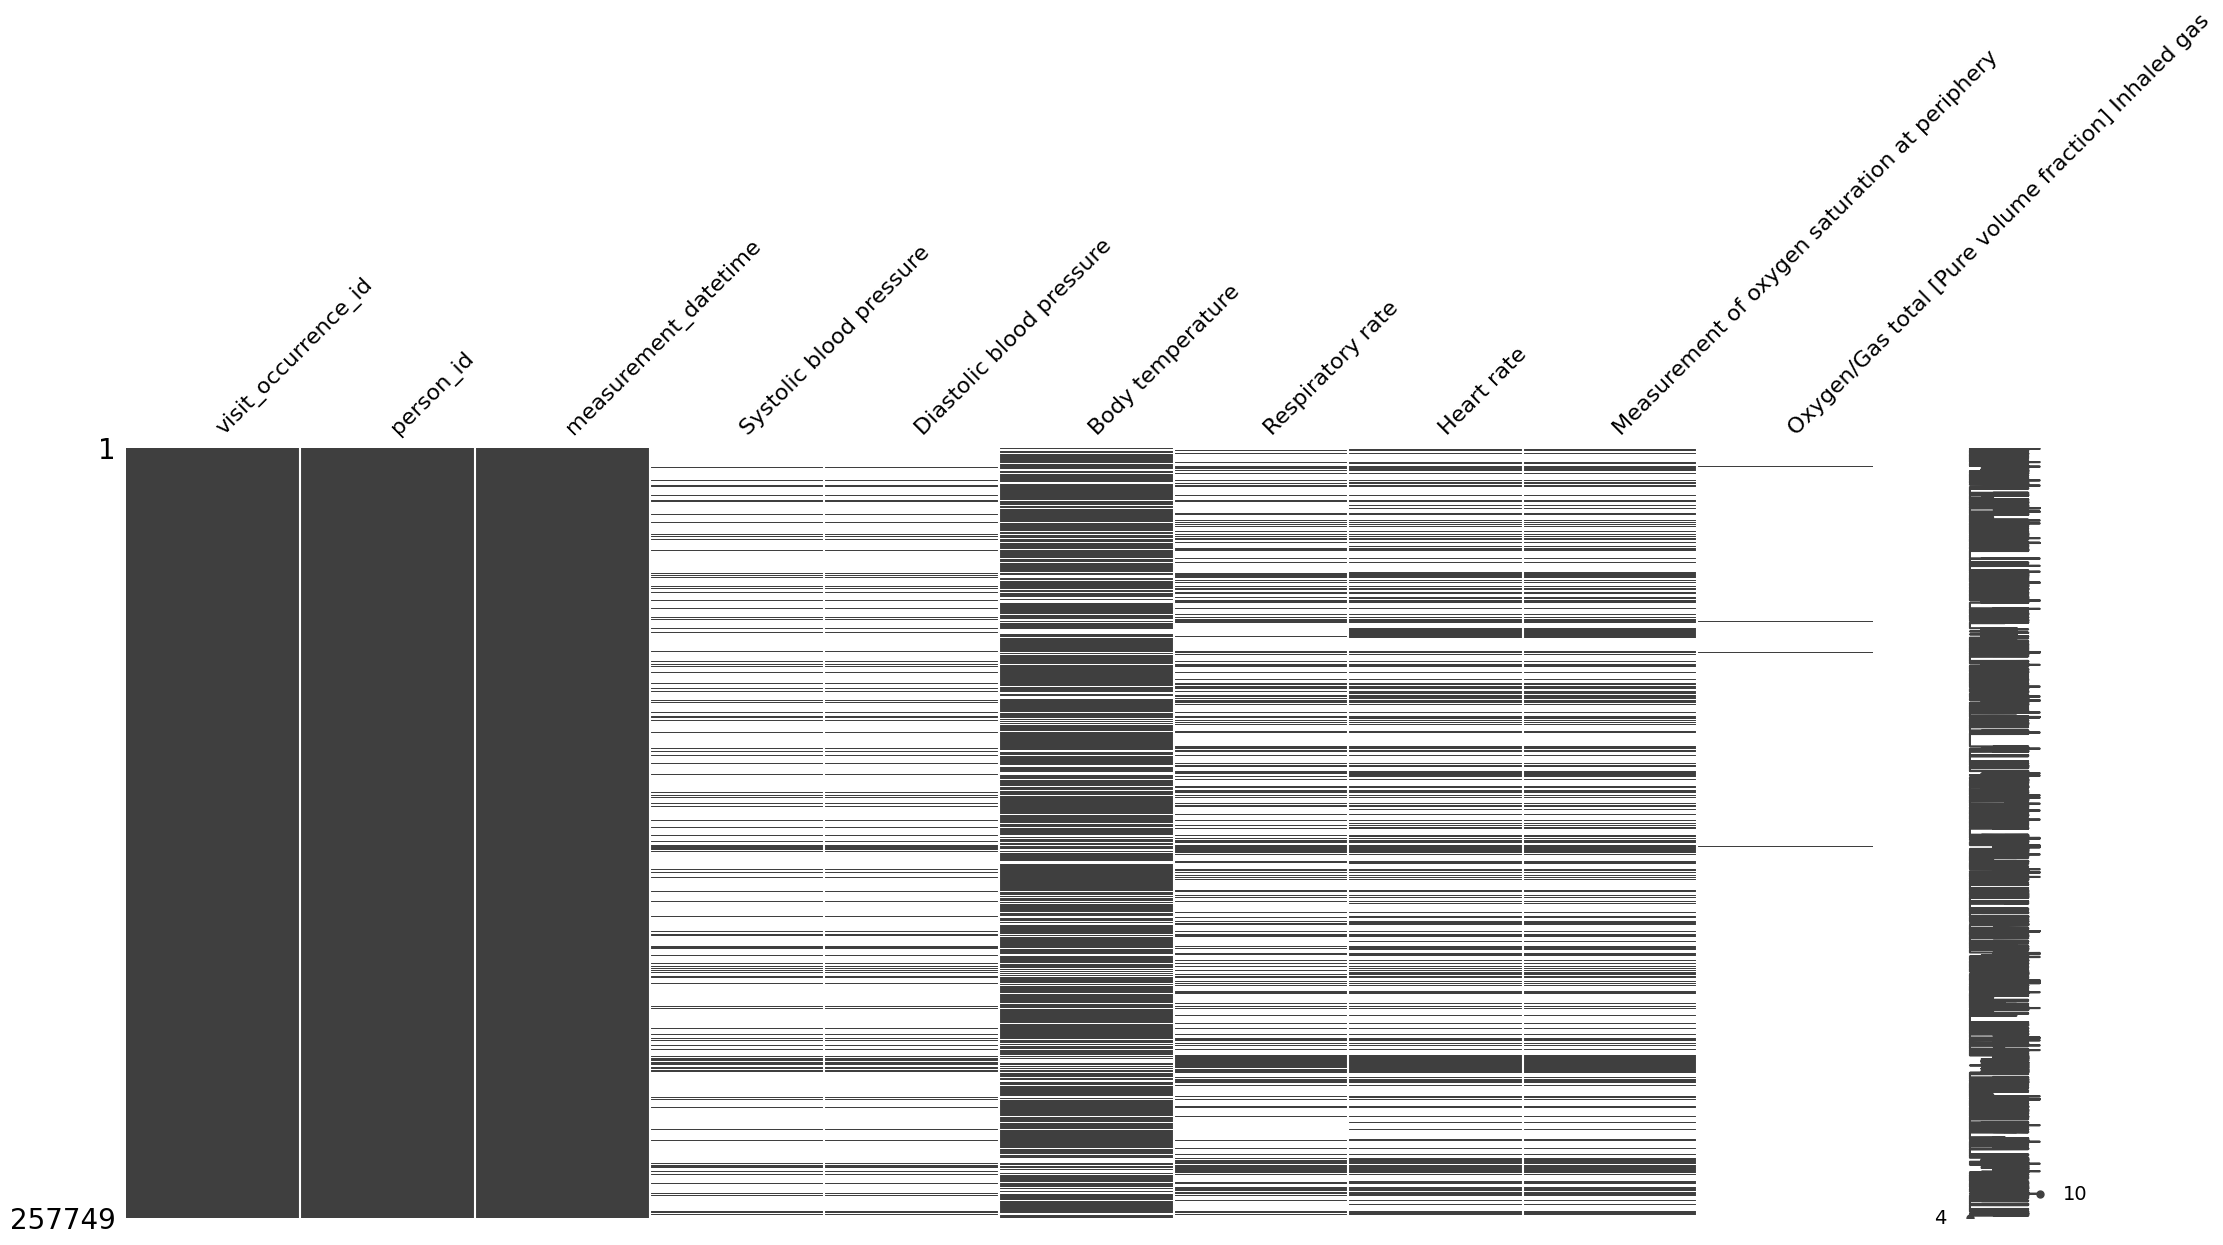

observation_train.csv


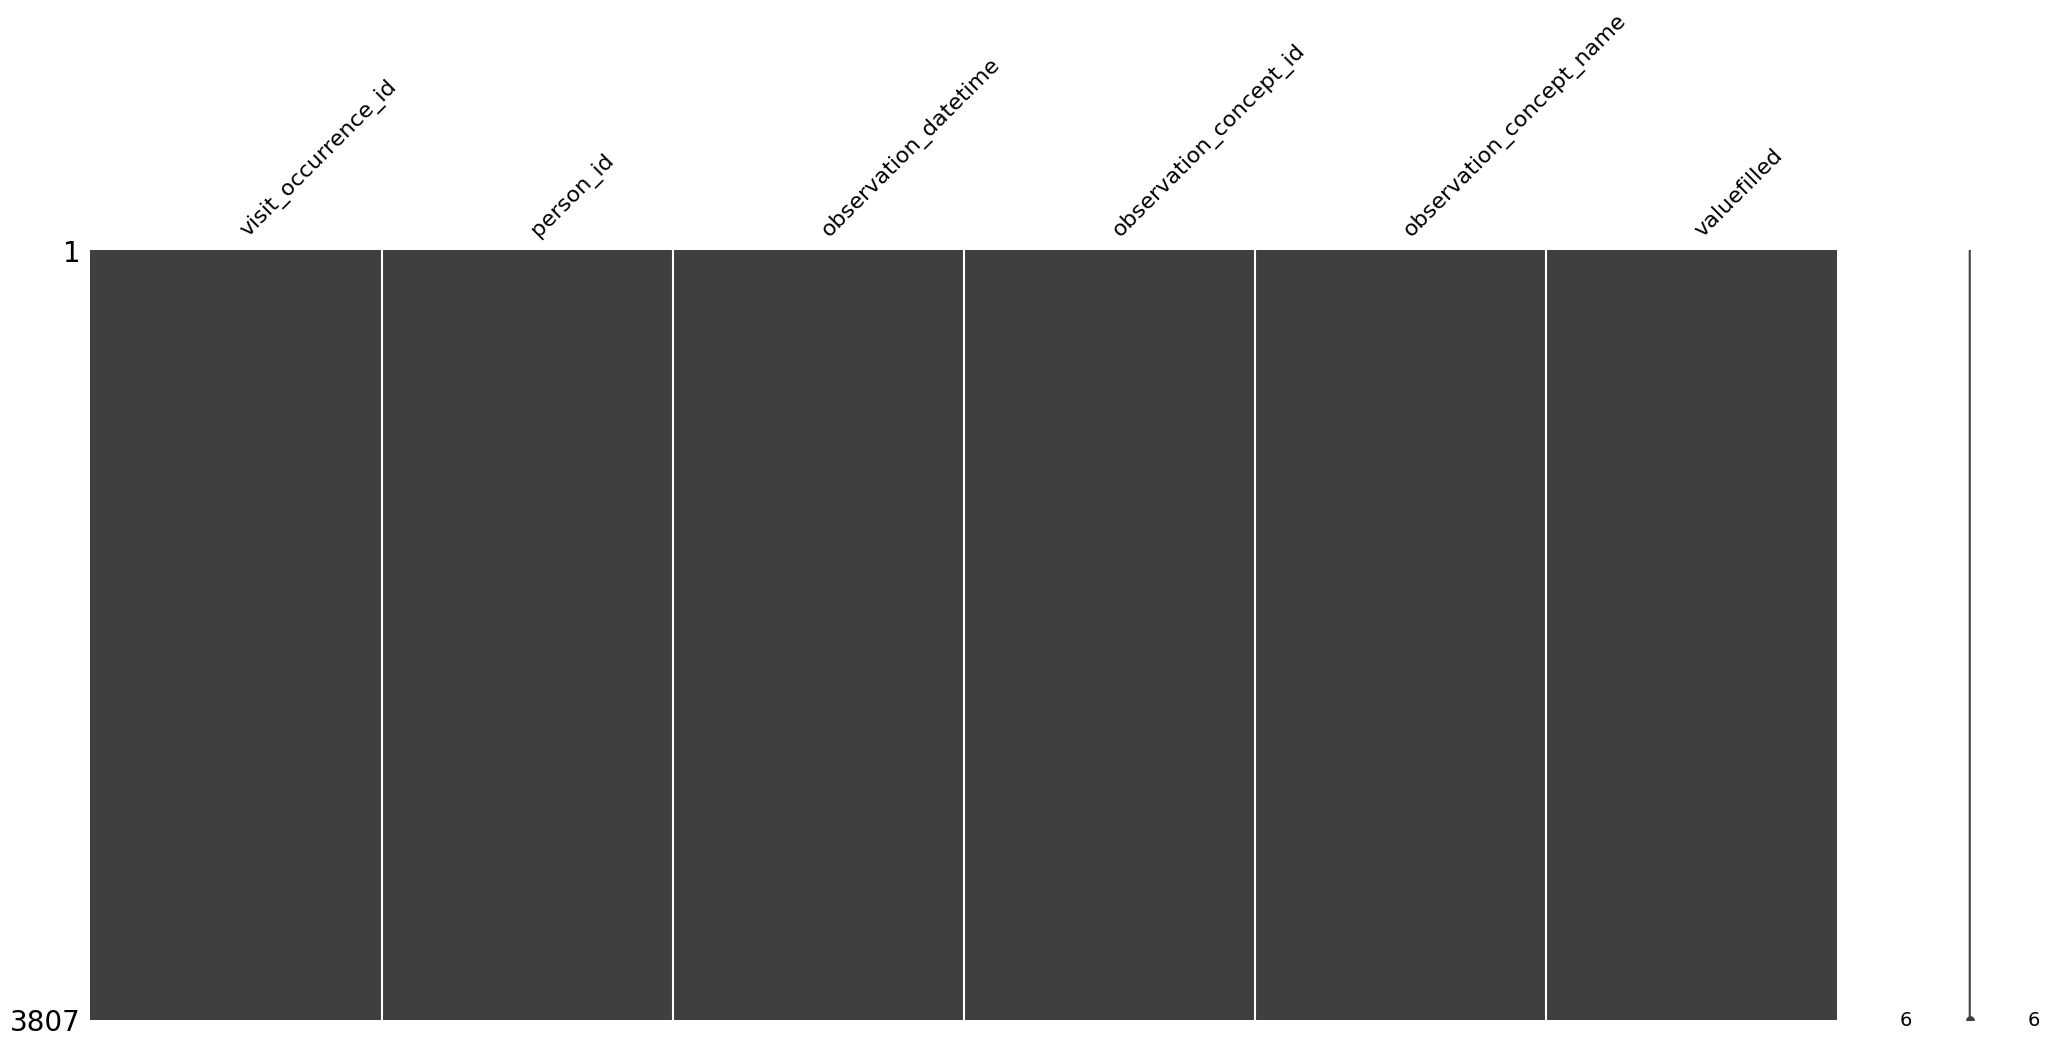

SepsisLabel_train.csv


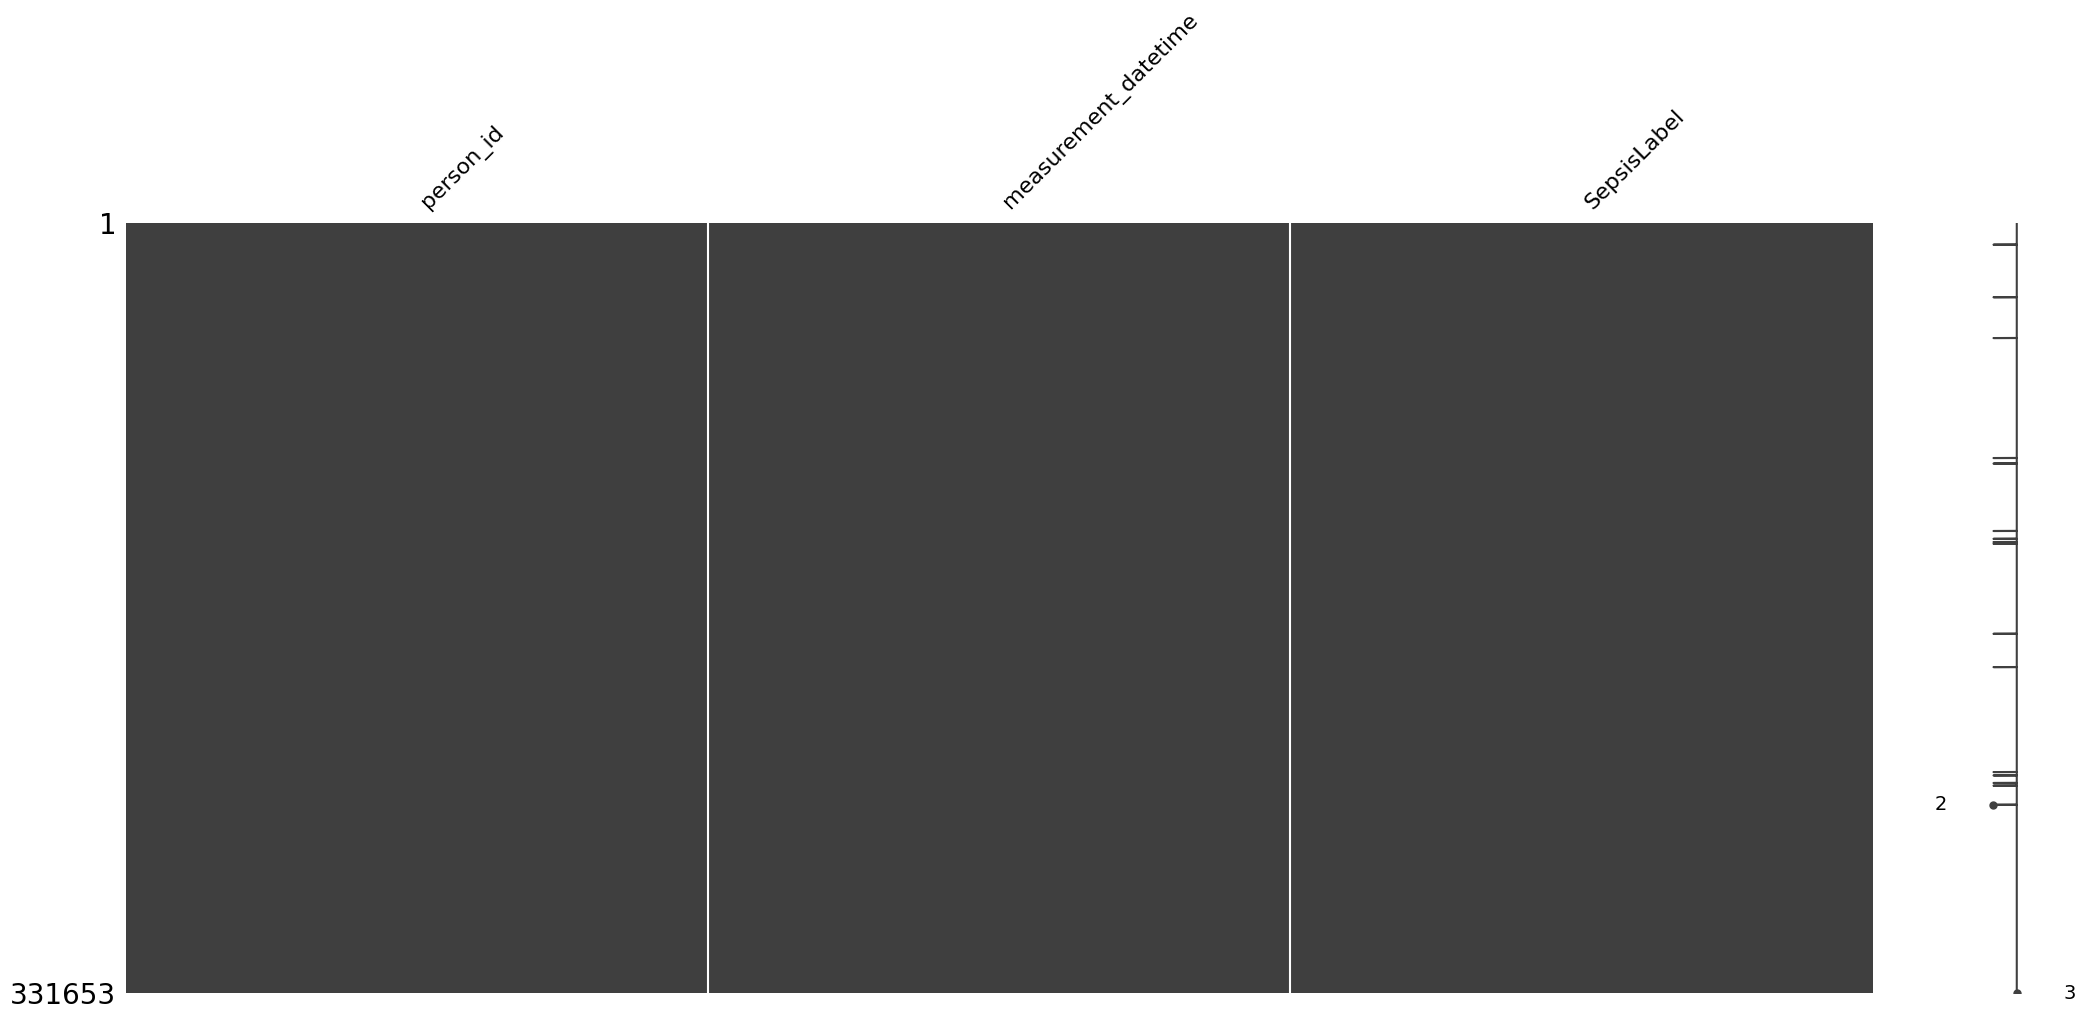

measurement_lab_train.csv


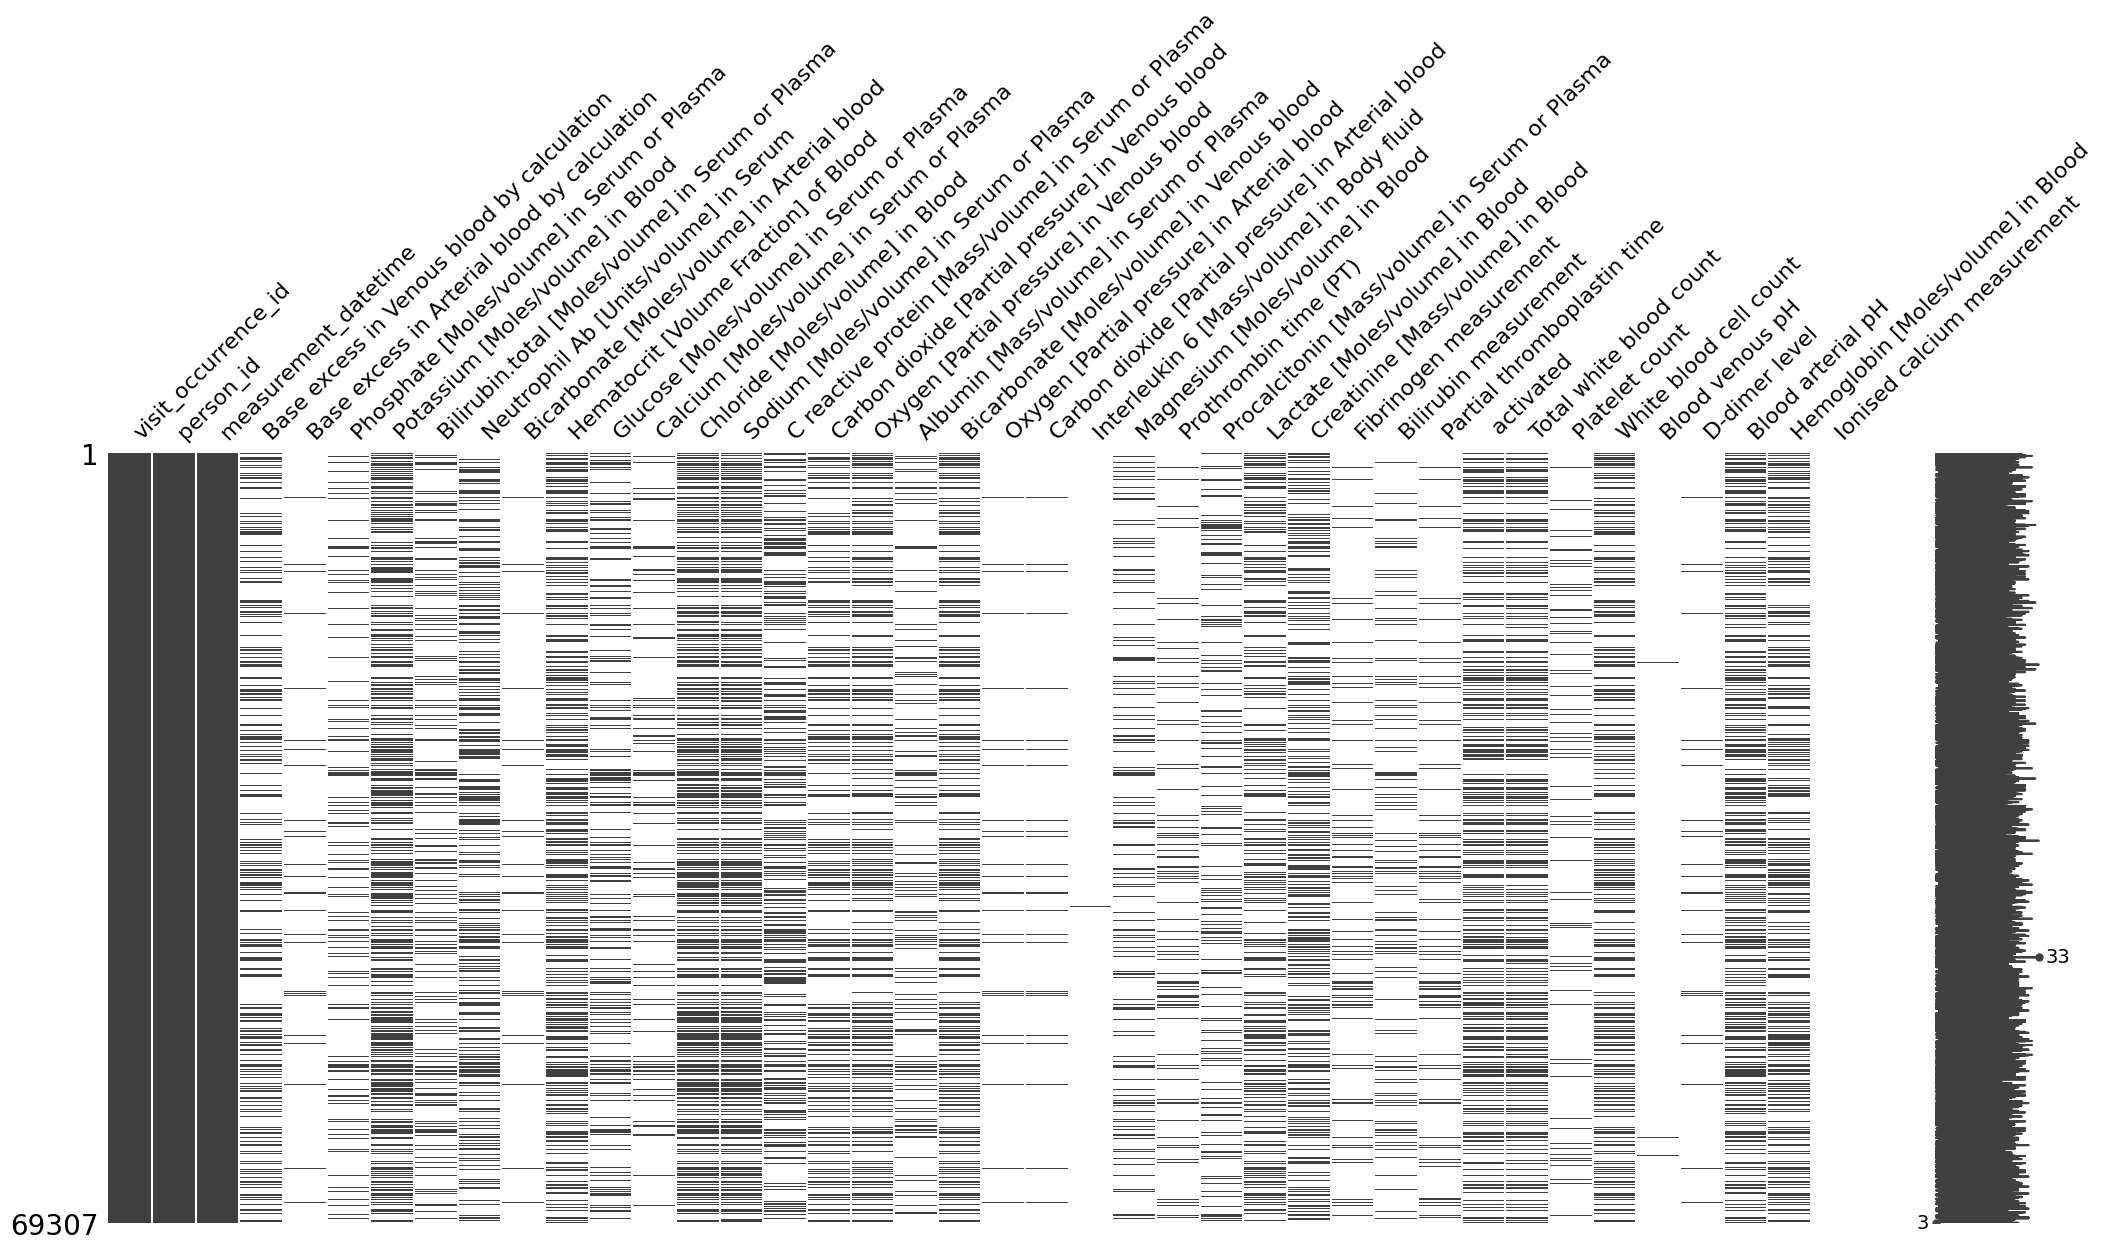

person_demographics_episode_train.csv


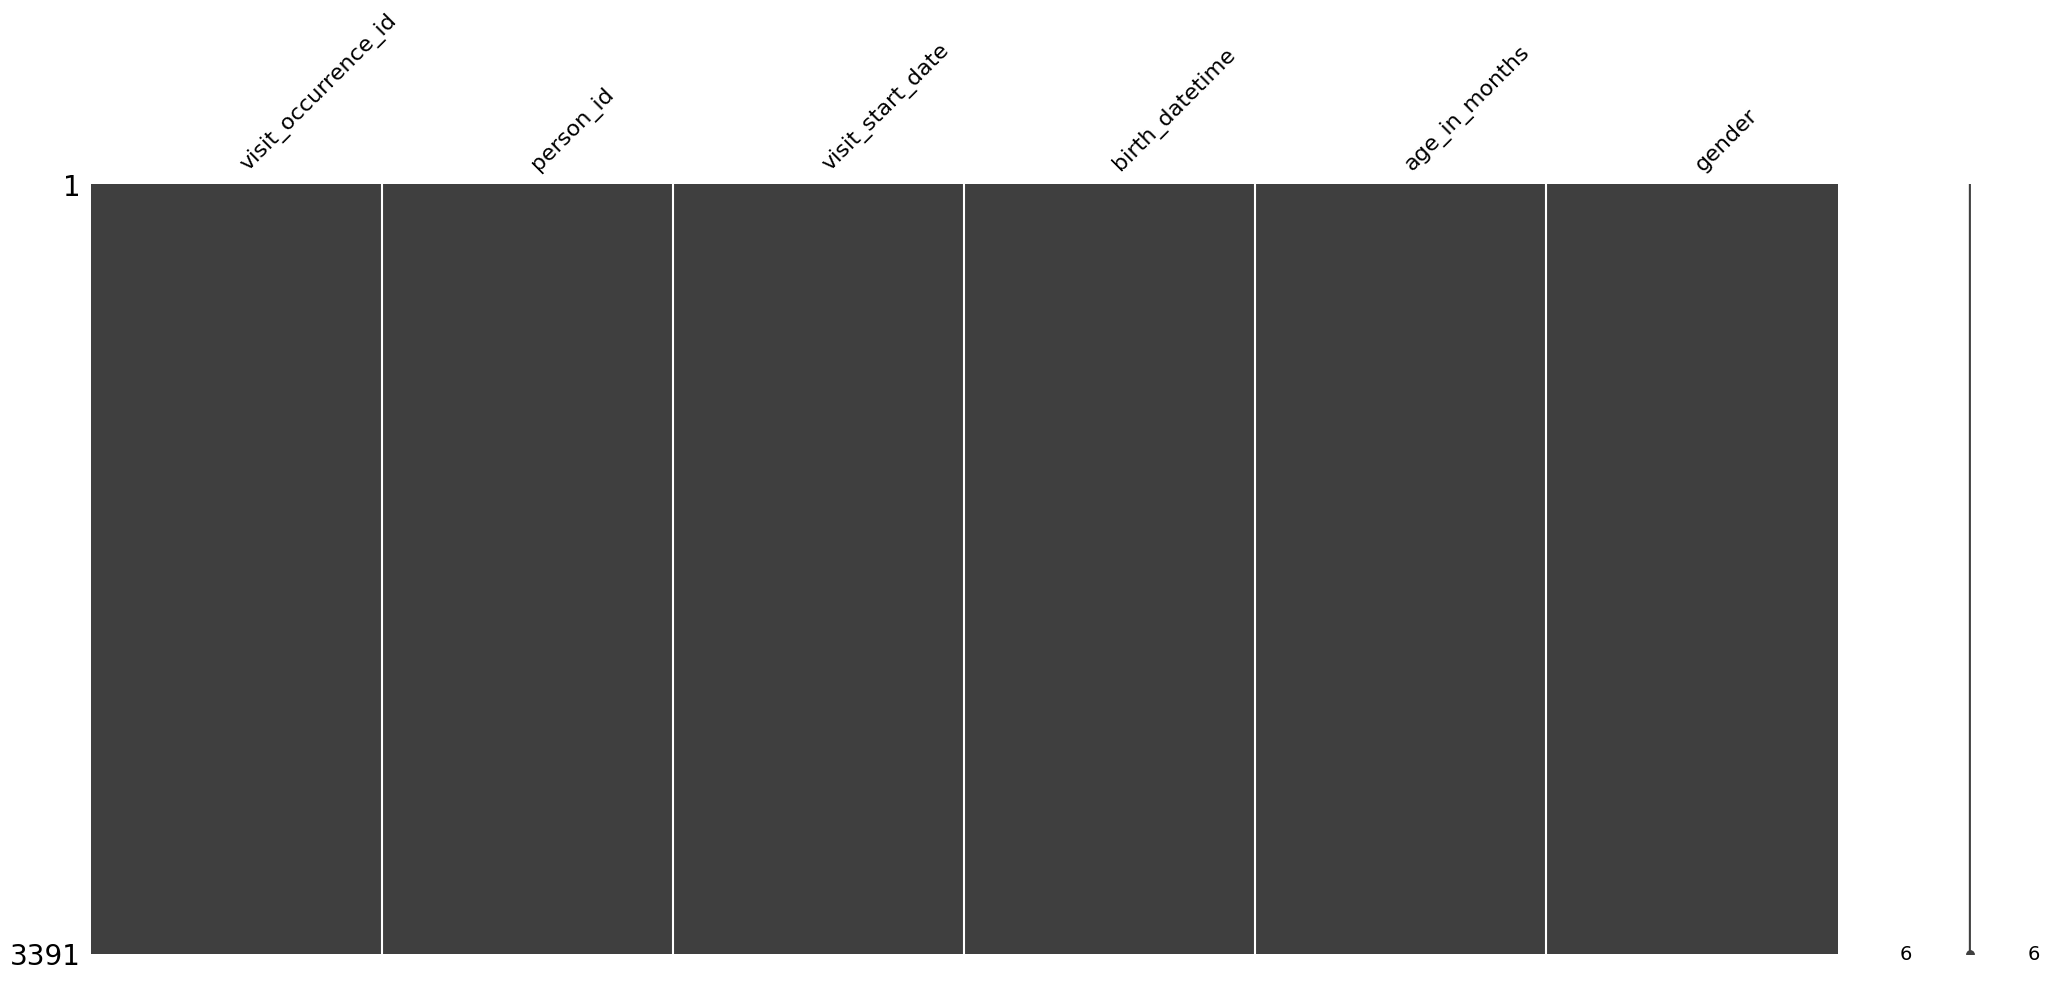

measurement_observation_train.csv


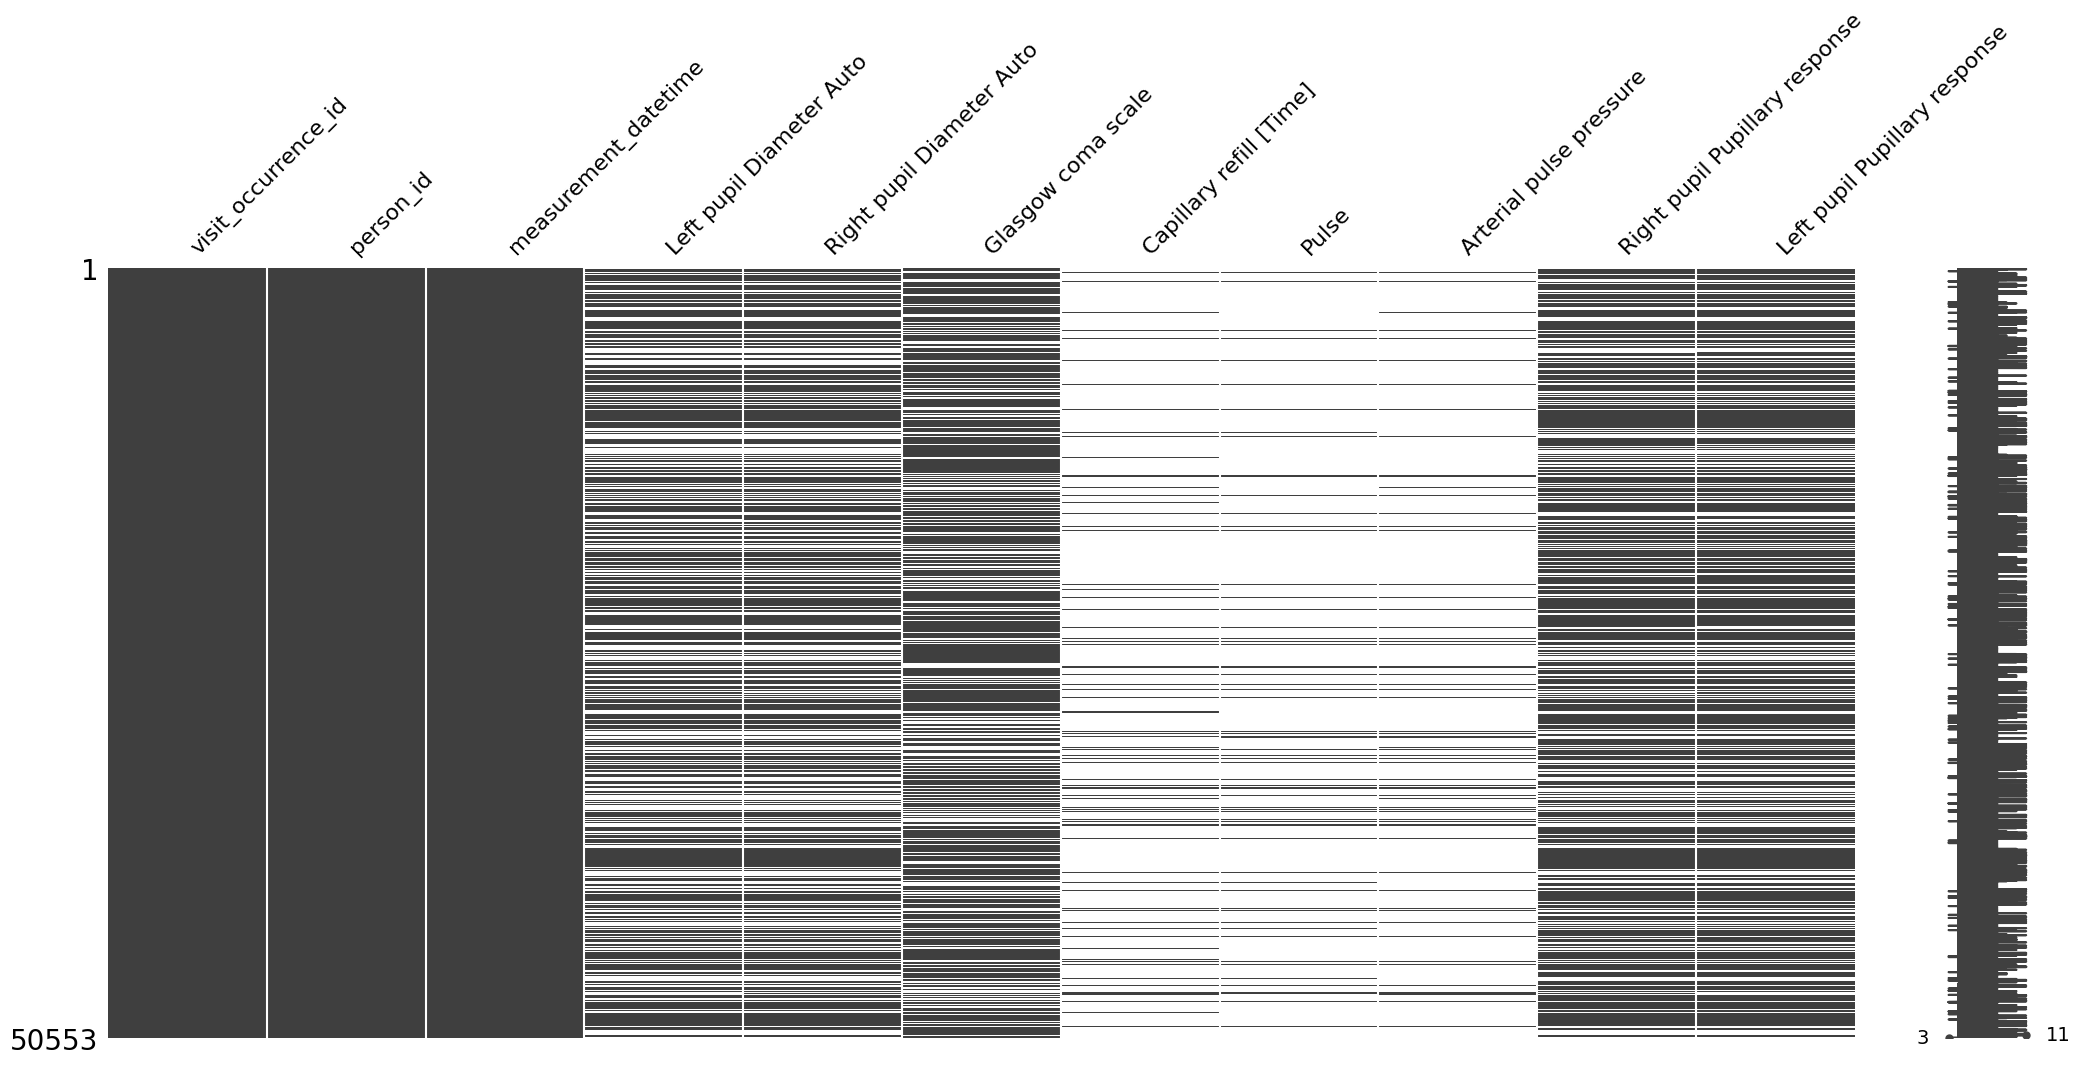

devices_train.csv


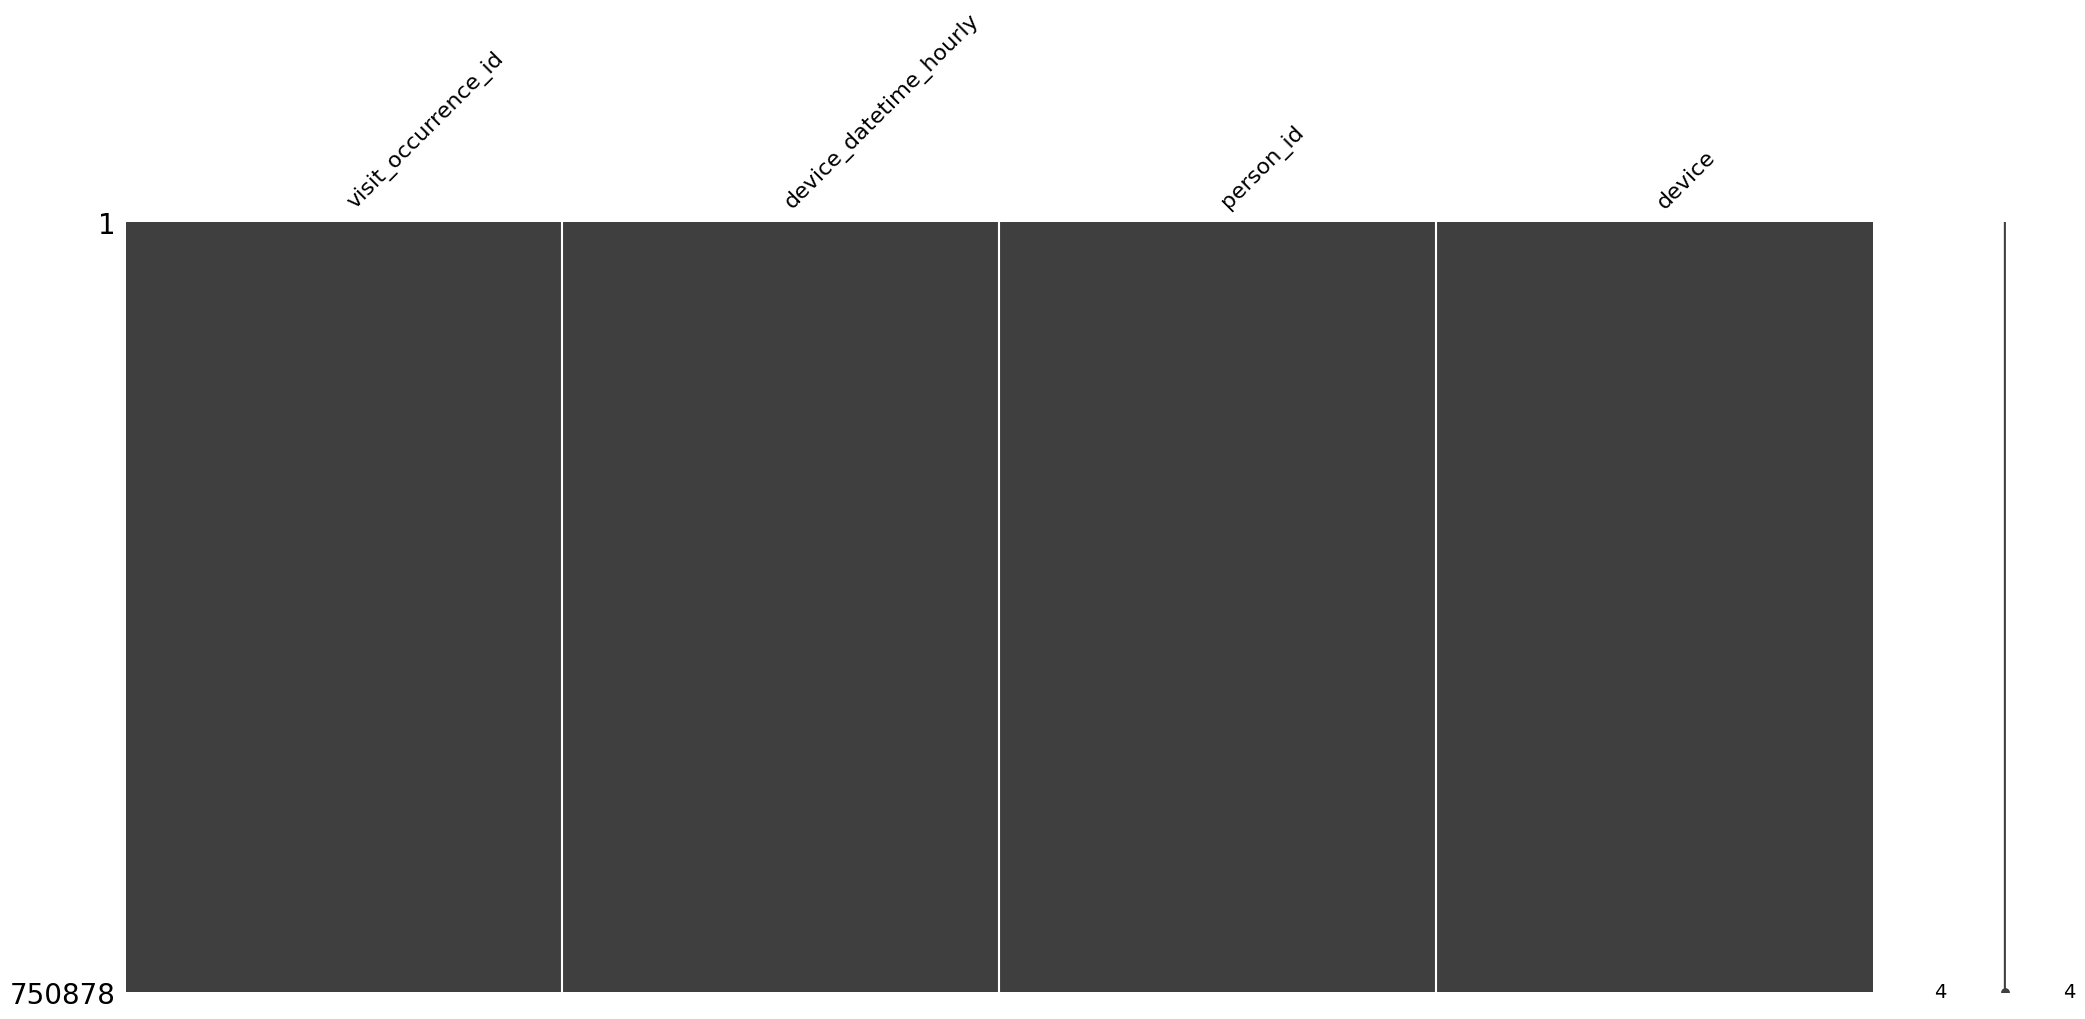

proceduresoccurrences_train.csv


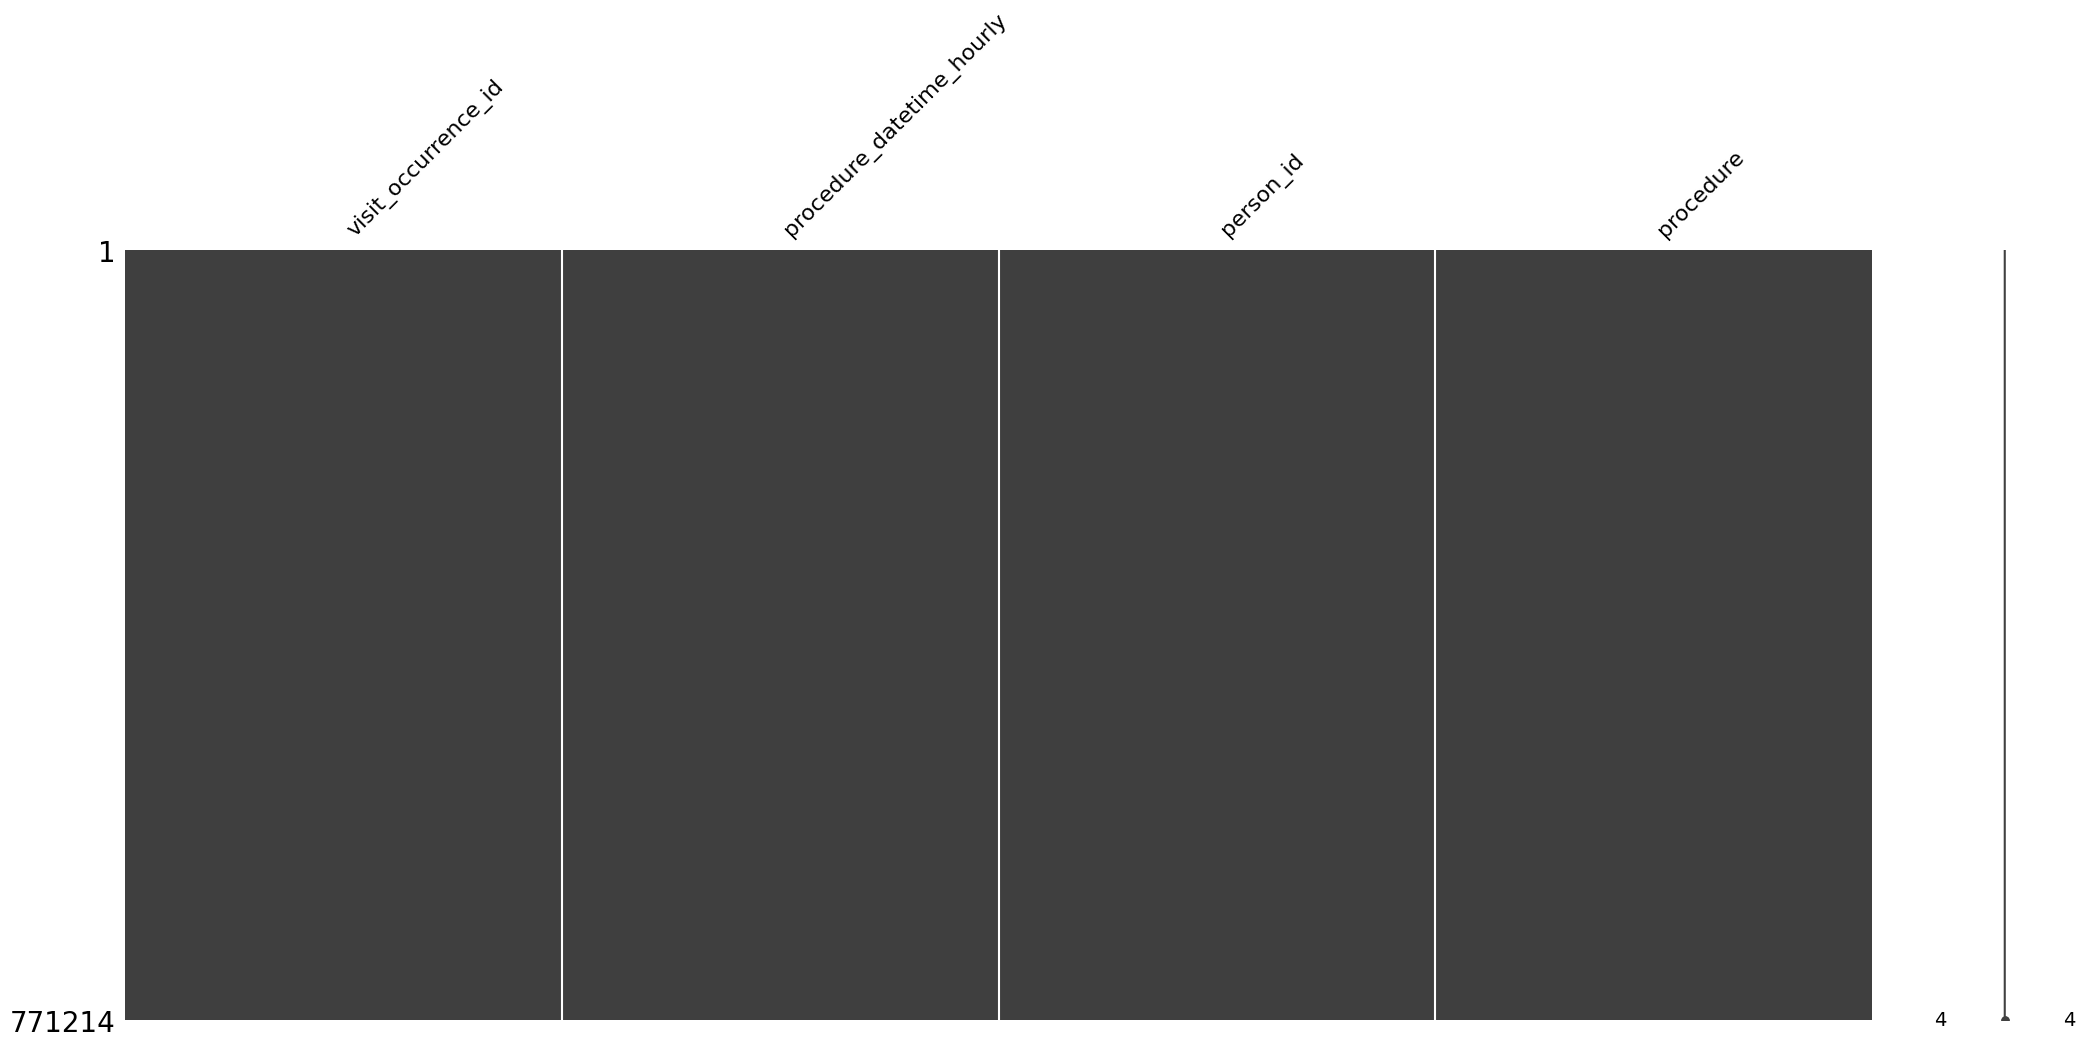

In [18]:
for name, df in csv_files.items():

    print(name)

    msno.matrix(df)

    plt.show()

In [19]:
for name, df in csv_files.items():

    missing = (
        df.isnull().sum()
        /len(df)
    )*100

    missing = missing[missing>0]

    print("="*80)
    print(name)

    print(missing.sort_values(
        ascending=False
    ))

drugsexposure_train.csv
route_concept_id    0.011906
dtype: float64
measurement_meds_train.csv
Oxygen/Gas total [Pure volume fraction] Inhaled gas    99.205817
Diastolic blood pressure                               84.449212
Systolic blood pressure                                84.444169
Respiratory rate                                       67.680185
Measurement of oxygen saturation at periphery          62.437488
Heart rate                                             62.376964
Body temperature                                       20.800469
dtype: float64
observation_train.csv
Series([], dtype: float64)
SepsisLabel_train.csv
measurement_datetime    0.004824
dtype: float64
measurement_lab_train.csv
Ionised calcium measurement                            100.000000
Interleukin 6 [Mass/volume] in Body fluid               99.911986
Blood venous pH                                         99.466143
Oxygen [Partial pressure] in Arterial blood             96.326489
Base excess in Arterial bl

In [20]:
for name, df in csv_files.items():

    print("="*80)
    print(name)

    print(
        df.describe(
            include='all'
        ).T
    )

drugsexposure_train.csv
                         count unique                  top    freq  \
visit_occurrence_id   184780.0    NaN                  NaN     NaN   
person_id             184780.0    NaN                  NaN     NaN   
drug_datetime_hourly    184780  43957  2024-04-11 09:00:00      28   
drug_concept_id         184780     50            milrinone   28142   
route_concept_id        184758      9          Intravenous  148975   

                                   mean               std       min  \
visit_occurrence_id   1083905306.700108  616748026.935452  933758.0   
person_id             1038042142.794621  636191193.213562  510305.0   
drug_datetime_hourly                NaN               NaN       NaN   
drug_concept_id                     NaN               NaN       NaN   
route_concept_id                    NaN               NaN       NaN   

                              25%           50%           75%           max  
visit_occurrence_id   538383673.0  1091189820.0  1

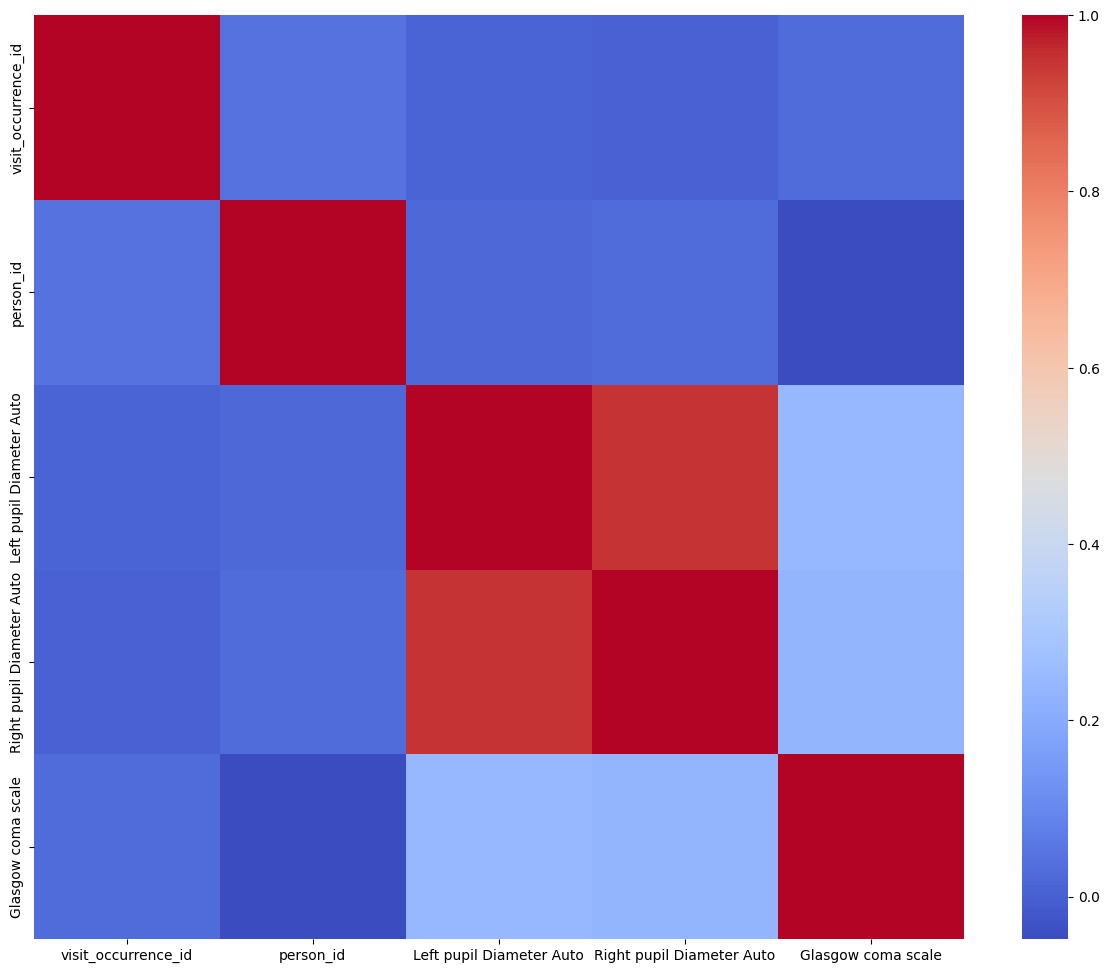

In [21]:
target_file = "measurement_observation_train.csv"

df = csv_files[target_file]

numeric = df.select_dtypes(
    include=np.number
)

corr = numeric.corr()

plt.figure(figsize=(15,12))

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.show()

In [22]:
for name, df in csv_files.items():

    datetime_cols = []

    for col in df.columns:

        if "date" in col.lower() or \
           "time" in col.lower():

            datetime_cols.append(col)

    if len(datetime_cols)>0:

        print(name)
        print(datetime_cols)
        print()

drugsexposure_train.csv
['drug_datetime_hourly']

measurement_meds_train.csv
['measurement_datetime']

observation_train.csv
['observation_datetime']

SepsisLabel_train.csv
['measurement_datetime']

measurement_lab_train.csv
['measurement_datetime', 'Prothrombin time (PT)', 'Partial thromboplastin time']

person_demographics_episode_train.csv
['visit_start_date', 'birth_datetime']

measurement_observation_train.csv
['measurement_datetime', 'Capillary refill [Time]']

devices_train.csv
['device_datetime_hourly']

proceduresoccurrences_train.csv
['procedure_datetime_hourly']



In [23]:
label_df.head()

,person_id,measurement_datetime,SepsisLabel
0,274096387,2024-12-03 20:00:00,0
1,1719359031,2024-04-20 09:00:00,0
2,2024544816,2021-07-14 07:00:00,0
3,213710896,2022-05-24 07:00:00,0
4,1335786468,2024-08-25 22:00:00,0


In [24]:
label_df.groupby(
    "person_id"
).size().describe()

,0
count,2649.000000
mean,125.199320
std,265.849177
min,1.000000
25%,27.000000
50%,55.000000
75%,125.000000
max,5792.000000


In [25]:
for name, df in csv_files.items():

    print("="*60)
    print(name)
    print("Shape:", df.shape)

drugsexposure_train.csv
Shape: (184780, 5)
measurement_meds_train.csv
Shape: (257749, 10)
observation_train.csv
Shape: (3807, 6)
SepsisLabel_train.csv
Shape: (331653, 3)
measurement_lab_train.csv
Shape: (69307, 40)
person_demographics_episode_train.csv
Shape: (3391, 6)
measurement_observation_train.csv
Shape: (50553, 11)
devices_train.csv
Shape: (750878, 4)
proceduresoccurrences_train.csv
Shape: (771214, 4)


In [26]:
for name, df in csv_files.items():

    print("\n")
    print("="*60)
    print(name)

    missing = df.isnull().sum()

    missing = missing[missing > 0]

    print(missing.sort_values(
        ascending=False
    ))



drugsexposure_train.csv
route_concept_id    22
dtype: int64


measurement_meds_train.csv
Oxygen/Gas total [Pure volume fraction] Inhaled gas    255702
Diastolic blood pressure                               217667
Systolic blood pressure                                217654
Respiratory rate                                       174445
Measurement of oxygen saturation at periphery          160932
Heart rate                                             160776
Body temperature                                        53613
dtype: int64


observation_train.csv
Series([], dtype: int64)


SepsisLabel_train.csv
measurement_datetime    16
dtype: int64


measurement_lab_train.csv
Ionised calcium measurement                            69307
Interleukin 6 [Mass/volume] in Body fluid              69246
Blood venous pH                                        68937
Oxygen [Partial pressure] in Arterial blood            66761
Base excess in Arterial blood by calculation           66760
Bicarbonate [Mol

In [27]:
for name, df in csv_files.items():

    print(name)

    print(
        "Duplicate Rows:",
        df.duplicated().sum()
    )

drugsexposure_train.csv
Duplicate Rows: 1851
measurement_meds_train.csv
Duplicate Rows: 0
observation_train.csv
Duplicate Rows: 0
SepsisLabel_train.csv
Duplicate Rows: 14
measurement_lab_train.csv
Duplicate Rows: 0
person_demographics_episode_train.csv
Duplicate Rows: 0
measurement_observation_train.csv
Duplicate Rows: 0
devices_train.csv
Duplicate Rows: 0
proceduresoccurrences_train.csv
Duplicate Rows: 0


In [28]:
for name, df in csv_files.items():

    print("\n")
    print(name)

    print(df.dtypes)



drugsexposure_train.csv
visit_occurrence_id      int64
person_id                int64
drug_datetime_hourly    object
drug_concept_id         object
route_concept_id        object
dtype: object


measurement_meds_train.csv
visit_occurrence_id                                      int64
person_id                                                int64
measurement_datetime                                    object
Systolic blood pressure                                float64
Diastolic blood pressure                               float64
Body temperature                                       float64
Respiratory rate                                       float64
Heart rate                                             float64
Measurement of oxygen saturation at periphery          float64
Oxygen/Gas total [Pure volume fraction] Inhaled gas    float64
dtype: object


observation_train.csv
visit_occurrence_id          int64
person_id                    int64
observation_datetime        object
obs

In [29]:
obs_df = csv_files[
    'measurement_observation_train.csv'
]

obs_df.head()

,visit_occurrence_id,person_id,measurement_datetime,Left pupil Diameter Auto,Right pupil Diameter Auto,Glasgow coma scale,Capillary refill [Time],Pulse,Arterial pulse pressure,Right pupil Pupillary response,Left pupil Pupillary response
0,933758,523870286,2023-12-07 11:00:00,3.0,3.0,15.0,NaN,NaN,NaN,Normal,Normal
1,933758,523870286,2023-12-07 13:00:00,3.0,3.0,15.0,Normal capillary filling,Present,Present,Normal,Normal
2,933758,523870286,2023-12-07 20:00:00,NaN,NaN,15.0,NaN,NaN,NaN,Normal,Normal
3,933758,523870286,2023-12-08 08:00:00,3.0,3.0,15.0,NaN,NaN,NaN,Normal,Normal
4,933758,523870286,2023-12-08 13:00:00,2.5,2.5,15.0,NaN,NaN,NaN,Normal,Normal


In [30]:
lab_df = csv_files[
    'measurement_lab_train.csv'
]

lab_df.head()

,visit_occurrence_id,person_id,measurement_datetime,Base excess in Venous blood by calculation,Base excess in Arterial blood by calculation,Phosphate [Moles/volume] in Serum or Plasma,Potassium [Moles/volume] in Blood,Bilirubin.total [Moles/volume] in Serum or Plasma,Neutrophil Ab [Units/volume] in Serum,Bicarbonate [Moles/volume] in Arterial blood,Hematocrit [Volume Fraction] of Blood,Glucose [Moles/volume] in Serum or Plasma,Calcium [Moles/volume] in Serum or Plasma,Chloride [Moles/volume] in Blood,Sodium [Moles/volume] in Serum or Plasma,C reactive protein [Mass/volume] in Serum or Plasma,Carbon dioxide [Partial pressure] in Venous blood,Oxygen [Partial pressure] in Venous blood,Albumin [Mass/volume] in Serum or Plasma,Bicarbonate [Moles/volume] in Venous blood,Oxygen [Partial pressure] in Arterial blood,Carbon dioxide [Partial pressure] in Arterial blood,Interleukin 6 [Mass/volume] in Body fluid,Magnesium [Moles/volume] in Blood,Prothrombin time (PT),Procalcitonin [Mass/volume] in Serum or Plasma,Lactate [Moles/volume] in Blood,Creatinine [Mass/volume] in Blood,Fibrinogen measurement,Bilirubin measurement,Partial thromboplastin time,activated,Total white blood count,Platelet count,White blood cell count,Blood venous pH,D-dimer level,Blood arterial pH,Hemoglobin [Moles/volume] in Blood,Ionised calcium measurement
0,933758,523870286,2023-12-06 17:00:00,-2.4,NaN,NaN,3.7,NaN,NaN,NaN,35.1,NaN,NaN,107.0,140.0,NaN,34.9,68.0,NaN,21.6,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,18.3,201.0,NaN,7.41,NaN,NaN,12.3,1.25,NaN
1,933758,523870286,2023-12-06 18:00:00,NaN,NaN,NaN,NaN,NaN,15.2,NaN,NaN,NaN,NaN,NaN,NaN,116.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.91,NaN,47.6,NaN,NaN,NaN,NaN,NaN,0.7,NaN,NaN,NaN,NaN,NaN,NaN
2,933758,523870286,2023-12-07 08:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.3,208.0,NaN,NaN,NaN,NaN,11.6,NaN,NaN
3,933758,523870286,2023-12-07 09:00:00,-1.2,NaN,NaN,3.5,NaN,9.3,NaN,NaN,NaN,NaN,110.0,141.0,75.0,33.3,30.0,NaN,22.4,NaN,NaN,NaN,NaN,NaN,1.25,1.2,48.2,NaN,NaN,NaN,NaN,NaN,1.1,7.44,NaN,NaN,NaN,1.12,NaN
4,933758,523870286,2023-12-08 23:00:00,NaN,NaN,NaN,4.0,0.0,NaN,NaN,37.4,136.0,NaN,105.0,138.0,NaN,NaN,53.0,NaN,23.3,NaN,NaN,NaN,NaN,NaN,NaN,0.7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.48,NaN,NaN,12.2,1.18,NaN


In [31]:
label_df = csv_files[
    'SepsisLabel_train.csv'
]

label_df.head()

,person_id,measurement_datetime,SepsisLabel
0,274096387,2024-12-03 20:00:00,0
1,1719359031,2024-04-20 09:00:00,0
2,2024544816,2021-07-14 07:00:00,0
3,213710896,2022-05-24 07:00:00,0
4,1335786468,2024-08-25 22:00:00,0


In [32]:
obs_df.columns
lab_df.columns
label_df.columns

Index(['person_id', 'measurement_datetime', 'SepsisLabel'], dtype='object')

In [33]:
label_df['SepsisLabel'].value_counts()

,count
SepsisLabel,
0,324779
1,6874


In [34]:
(
label_df['SepsisLabel']
.value_counts(normalize=True)
*100
)

,proportion
SepsisLabel,
0,97.927352
1,2.072648


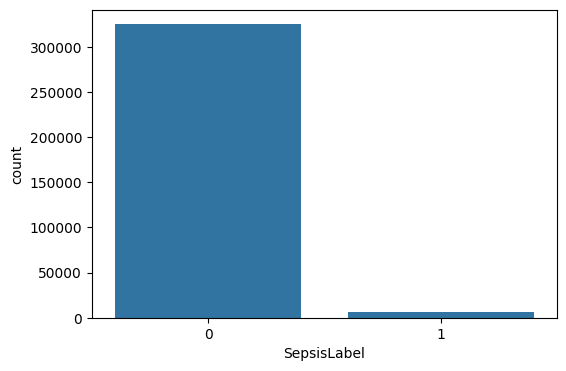

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    x='SepsisLabel',
    data=label_df
)

plt.show()

In [36]:
label_df['person_id'].nunique()

2649

In [37]:
label_df[
    label_df['SepsisLabel']==1
]['person_id'].nunique()

97

In [38]:
label_df[
    label_df['SepsisLabel']==0
]['person_id'].nunique()

2649

In [39]:
demo_df = csv_files[
    'person_demographics_episode_train.csv'
]

merged = demo_df.merge(
    label_df,
    on='person_id'
)

merged.head()

,visit_occurrence_id,person_id,visit_start_date,birth_datetime,age_in_months,gender,measurement_datetime,SepsisLabel
0,1933014304,1354145347,2021-12-15,2002-05-30,235,MALE,2021-12-15 17:00:00,0
1,1933014304,1354145347,2021-12-15,2002-05-30,235,MALE,2021-12-16 06:00:00,0
2,1933014304,1354145347,2021-12-15,2002-05-30,235,MALE,2021-12-17 13:00:00,0
3,1933014304,1354145347,2021-12-15,2002-05-30,235,MALE,2021-12-16 20:00:00,0
4,1933014304,1354145347,2021-12-15,2002-05-30,235,MALE,2021-12-16 15:00:00,0


In [41]:
obs_df['measurement_name'].value_counts()

KeyError: 'measurement_name'